In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("C:\\Users\\Dambatta\\student_admission_record_dirty.csv")
df

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
1,Waqar,21.0,Female,99.0,60.73,Karachi,NaN
2,Bushra,17.0,Male,89.0,NaN,Islamabad,Accepted
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
4,Bilal,20.0,Male,65.0,61.13,Lahore,NaN
...,...,...,...,...,...,...,...
152,Ali,19.0,Female,85.0,78.09,Quetta,Accepted
153,Bilal,17.0,Female,81.0,84.40,Islamabad,Rejected
154,Fatima,21.0,Female,98.0,50.86,Multan,Accepted
155,Shoaib,-1.0,Male,91.0,80.12,Quetta,Accepted


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    147 non-null    object 
 1   Age                     147 non-null    float64
 2   Gender                  147 non-null    object 
 3   Admission Test Score    146 non-null    float64
 4   High School Percentage  146 non-null    float64
 5   City                    147 non-null    object 
 6   Admission Status        147 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.7+ KB


In [8]:
df.dropna( inplace = True)

In [9]:
len(df)

100

In [10]:
df.tail()

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
152,Ali,19.0,Female,85.0,78.09,Quetta,Accepted
153,Bilal,17.0,Female,81.0,84.40,Islamabad,Rejected
154,Fatima,21.0,Female,98.0,50.86,Multan,Accepted
155,Shoaib,-1.0,Male,91.0,80.12,Quetta,Accepted
156,Maaz,17.0,Male,88.0,86.85,Lahore,Accepted


In [11]:
df.loc[df['Age'] < 0, 'Age'] = np.nan

In [12]:
df.tail()

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
152,Ali,19.0,Female,85.0,78.09,Quetta,Accepted
153,Bilal,17.0,Female,81.0,84.40,Islamabad,Rejected
154,Fatima,21.0,Female,98.0,50.86,Multan,Accepted
155,Shoaib,NaN,Male,91.0,80.12,Quetta,Accepted
156,Maaz,17.0,Male,88.0,86.85,Lahore,Accepted


In [13]:
df.dropna( inplace = True)

In [14]:
df.head()

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
7,Rabia,20.0,Female,82.0,55.67,Lahore,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected
10,Shafiq,17.0,Male,78.0,-10.00,Quetta,Rejected


In [15]:
len(df)

97

In [16]:
df['Admission Test Score'] = df['Admission Test Score'].clip(0, 100)
df['High School Percentage'] = df['High School Percentage'].clip(0, 100)

In [17]:
df.head()

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
7,Rabia,20.0,Female,82.0,55.67,Lahore,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected
10,Shafiq,17.0,Male,78.0,0.00,Quetta,Rejected


In [18]:
df

,Name,Age,Gender,Admission Test Score,High School Percentage,City,Admission Status
0,Shehroz,24.0,Female,50.0,68.90,Quetta,Rejected
3,Aliya,17.0,Male,55.0,85.29,Karachi,Rejected
7,Rabia,20.0,Female,82.0,55.67,Lahore,Accepted
9,Kamran,18.0,Male,53.0,98.98,Multan,Rejected
10,Shafiq,17.0,Male,78.0,0.00,Quetta,Rejected
...,...,...,...,...,...,...,...
151,Asad,20.0,Female,95.0,52.40,Rawalpindi,Rejected
152,Ali,19.0,Female,85.0,78.09,Quetta,Accepted
153,Bilal,17.0,Female,81.0,84.40,Islamabad,Rejected
154,Fatima,21.0,Female,98.0,50.86,Multan,Accepted


In [23]:
valid_status = df[df['Admission Status'].isin(['Accepted','Rejected'])]
acceptance_rate = (valid_status['Admission Status'].eq('Accepted').sum() / len(valid_status)) * 100
print("Acceptance rate = ",acceptance_rate)

Acceptance rate =  46.391752577319586


In [28]:
gender_counts = df['Gender'].value_counts()
male_count = gender_counts.get('Male')
female_count = gender_counts.get('Female')
gender_ratio = male_count / female_count 

print("gender_ratio = ",gender_ratio)

gender_ratio =  0.7962962962962963


In [30]:
# Since there is no Program column i will treat City as the proxy for program demand.
# We compute:
# that is i will compute Number Applicants per City

In [32]:
top_cities = df['City'].value_counts().head(5)
print("top cities", top_cities)

top cities City
Multan      19
Quetta      18
Karachi     17
Peshawar    15
Lahore      11
Name: count, dtype: int64


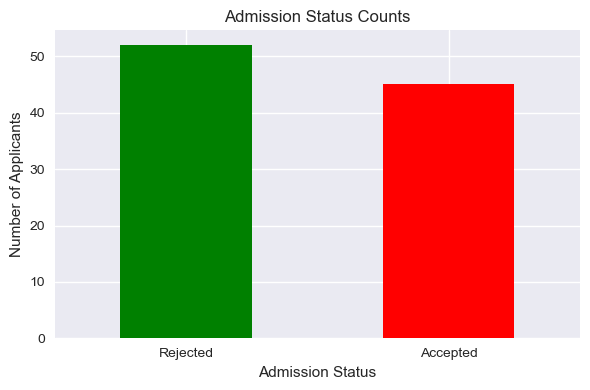

In [35]:
# --- Visualization 1: Bar Chart for Acceptance vs Rejection ---
status_counts = valid_status['Admission Status'].value_counts()
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(6,4))
status_counts.plot(kind='bar', color=['green', 'red'])
plt.title("Admission Status Counts")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

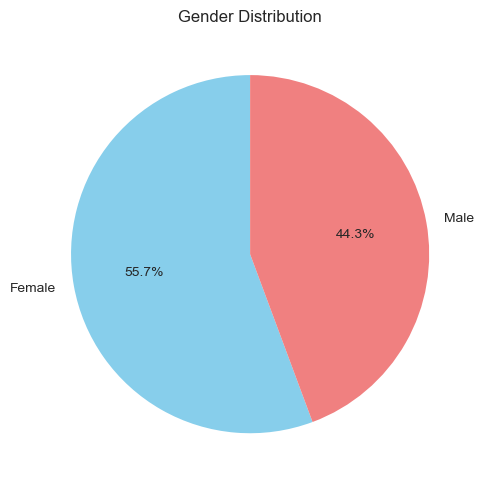

In [36]:
plt.figure(figsize=(5,5))
gender_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral', 'lightgreen'])
plt.title("Gender Distribution")
plt.ylabel('')
plt.tight_layout()
plt.show()



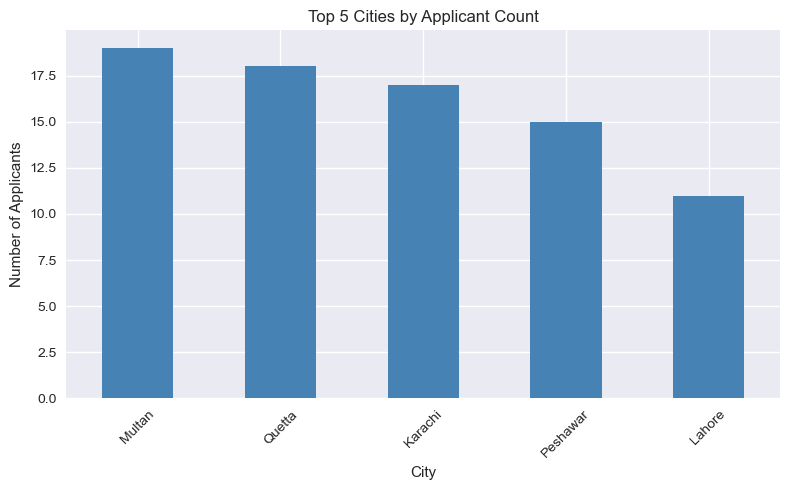

In [40]:
plt.figure(figsize=(8,5))
top_cities.plot(kind='bar', color='steelblue')
plt.title("Top 5 Cities by Applicant Count")
plt.ylabel("Number of Applicants")
plt.xlabel("City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()







In [41]:
print("Computed acceptance rate, gender ratios, and top 10 cities by demand. Generated 3 visualizations: bar chart (admission status), pie chart (gender), and histogram (top cities).")


Computed acceptance rate, gender ratios, and top 10 cities by demand. Generated 3 visualizations: bar chart (admission status), pie chart (gender), and histogram (top cities).


In [42]:
summary = {
    "Acceptance Rate (%)": [acceptance_rate],
    "Male Applicants": [male_count],
    "Female Applicants": [female_count],
    "Gender Ratio (Male/Female)": [gender_ratio]
}

summary_df = pd.DataFrame(summary)

top_cities_df = top_cities.reset_index()
top_cities_df.columns = ["City", "Applicants"]


summary_df.to_csv("summary_report.csv", index=False)
top_cities_df.to_csv("top_cities_report.csv", index=False)

